In [1]:
from os.path import basename, exists


def download(url):
    filename = basename(url)
    if not exists(filename):
        from urllib.request import urlretrieve

        local, _ = urlretrieve(url, filename)
        print("Downloaded " + local)


download("https://github.com/AllenDowney/ThinkStats/raw/v3/nb/thinkstats.py")

In [2]:
try:
    import empiricaldist
except ImportError:
    %pip install empirical dist

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from thinkstats import decorate

In [4]:
from empiricaldist import FreqTab

In [5]:
t = [1.0, 2.0, 2.0, 3.0, 5.0]

In [6]:
ftab = FreqTab.from_seq(t)
ftab

,freqs
1.0,1
2.0,2
3.0,1
5.0,1


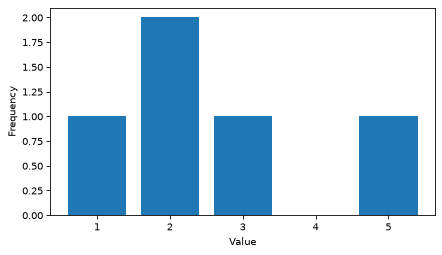

In [7]:
ftab.bar()
decorate(xlabel = 'Value', ylabel ='Frequency')

In [8]:
ftab[2.0]

np.int64(2)

In [9]:
ftab(2.0)

np.int64(2)

In [10]:
ftab(4.0)

0

In [11]:
ftab.qs

array([1., 2., 3., 5.])

In [12]:
ftab.fs

array([1, 2, 1, 1])

In [13]:
for x, freq in ftab.items():
    print(x, freq)

1.0 1
2.0 2
3.0 1
5.0 1


In [14]:
try: 
    import statadict
except ImportError:
    %pip install statadict
    

In [15]:
download("https://github.com/AllenDowney/ThinkStats/raw/v3/nb/nsfg.py")
download("https://github.com/AllenDowney/ThinkStats/raw/v3/data/2002FemPreg.dct")
download("https://github.com/AllenDowney/ThinkStats/raw/v3/data/2002FemPreg.dat.gz")

In [16]:
from nsfg import read_fem_preg

preg = read_fem_preg()


/home/axiuc-fedor/think-stats/notebooks/nsfg.py:220: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["totalwgt_lb"] = df.birthwgt_lb + df.birthwgt_oz / 16.0


In [17]:
live = preg.query('outcome == 1')

In [18]:
ftab_lb = FreqTab.from_seq(live["birthwgt_lb"], name='birth')

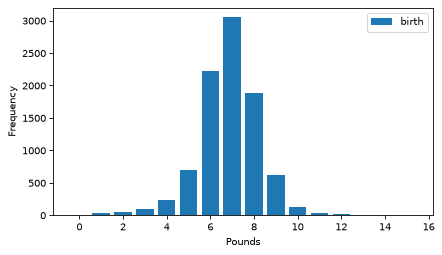

In [19]:
ftab_lb.bar()
decorate(xlabel = 'Pounds', ylabel = 'Frequency')

In [20]:
ftab_lb.idxmax()

np.float64(7.0)

In [21]:
ftab_lb.mode()

np.float64(7.0)

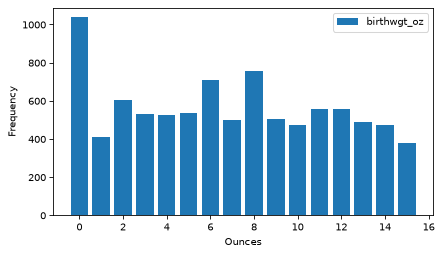

In [22]:
ftab_oz = FreqTab.from_seq(live['birthwgt_oz'], name = 'birthwgt_oz')
ftab_oz.bar()
decorate(xlabel = 'Ounces', ylabel = 'Frequency')

In [23]:
ftab_age = FreqTab.from_seq(live['agepreg'], name = 'agepreg')

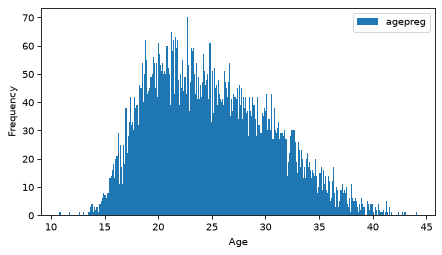

In [24]:
ftab_age.bar(width = 0.1)
decorate(xlabel = 'Age', ylabel = 'Frequency')

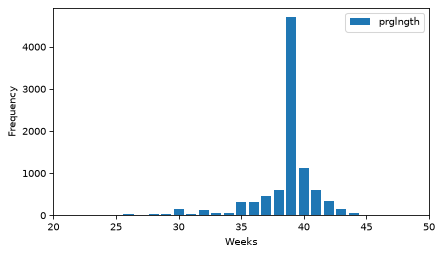

In [25]:
ftab_length = FreqTab.from_seq(live['prglngth'], name = 'prglngth')
ftab_length.bar()
decorate(xlabel = 'Weeks', ylabel = 'Frequency', xlim = [20,50])

In [26]:
def smallest(ftab, n=10):
    return ftab[:n]

In [27]:
smallest(ftab_length)

prglngth
0     1
4     1
9     1
13    1
17    2
18    1
19    1
20    1
21    2
22    7
Name: prglngth, dtype: int64

In [28]:
def largest(ftab, n=10):
    return ftab[-n:]

In [29]:
largest(ftab_length)

prglngth
40    1116
41     587
42     328
43     148
44      46
45      10
46       1
47       1
48       7
50       2
Name: prglngth, dtype: int64

In [30]:
firsts = live.query('birthord == 1')
others = live.query("birthord != 1")

In [31]:
ftab_first = FreqTab.from_seq(firsts['prglngth'], name = 'firsts')
ftab_others = FreqTab.from_seq(others['prglngth'], name = 'others')

In [32]:
def two_bar_plots(ftab1, ftab2, width = 0.45):
    ftab1.bar(align = 'edge', width = width)
    ftab2.bar(align = 'edge')

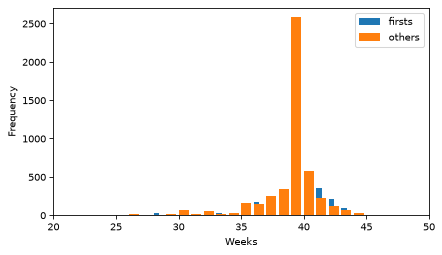

In [33]:
two_bar_plots(ftab_first, ftab_others)
decorate(xlabel = 'Weeks', ylabel = 'Frequency', xlim = [20,50])

In [34]:
firsts['prglngth'].count(), others['prglngth'].count()

(np.int64(4413), np.int64(4735))

In [35]:
first_mean = firsts['prglngth'].mean()
other_mean = others['prglngth'].mean()
first_mean, other_mean

(np.float64(38.60095173351461), np.float64(38.52291446673706))

In [36]:
diff = first_mean - other_mean

diff, diff * 7 * 24

(np.float64(0.07803726677754952), np.float64(13.11026081862832))

In [37]:
diff / live['prglngth'].mean() * 100

np.float64(0.20237586646738304)

In [38]:
diff / live['prglngth'].std()

np.float64(0.028877623375210403)

In [39]:
group1, group2 = firsts['prglngth'], others['prglngth']

In [40]:
v1, v2 = group1.var(), group2.var()

In [42]:
n1, n2 = group1.count(), group2.count()
pooled_var = (n1*v1 +n2*v2) / (n1+n2)

In [44]:
np.sqrt(pooled_var)

np.float64(2.7022108144953862)

In [46]:
firsts['prglngth'].std(), others['prglngth'].std()

(np.float64(2.7919014146687204), np.float64(2.6158523504392375))

In [49]:
def cohen_effect_size(group1, group2):
    diff = group1.mean() - group2.mean()

    v1, v2 = group1.var(), group2.var()
    n1, n2 = group1.count(), group2.count()
    pooled_var = (n1*v1 + n2*v2)/(n1+n2)

    return diff / np.sqrt(pooled_var)

In [51]:
cohen_effect_size(group1, group2)

np.float64(0.028879044654449834)

In [53]:
download("https://github.com/AllenDowney/ThinkStats/raw/v3/data/2002FemResp.dct")
download("https://github.com/AllenDowney/ThinkStats/raw/v3/data/2002FemResp.dat.gz")

In [59]:
from nsfg import read_fem_resp

resp = read_fem_resp()
resp.shape

/home/axiuc-fedor/think-stats/notebooks/nsfg.py:191: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  resp["agemarry"] = (resp.cmmarrhx - resp.cmbirth) / 12.0
/home/axiuc-fedor/think-stats/notebooks/nsfg.py:192: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  resp["age"] = (resp.cmintvw - resp.cmbirth) / 12.0
/home/axiuc-fedor/think-stats/notebooks/nsfg.py:195: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns

(7643, 3092)

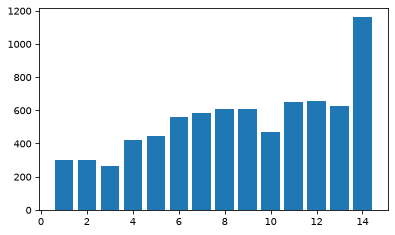

In [62]:
#EXERCISE 2.1

totalinc_ft = FreqTab.from_seq(resp['totincr'], name = 'total_income')
totalinc_ft.bar()
